Diagnosis Of Pneumonia By CNN Classifier

In [ ]:
Pneumonia is a serious respiratory disease that causes inflammation in the air sacs of the lungs. Early and accurate diagnosis is essential to reduce complications and improve patient outcomes. Traditionally, pneumonia is diagnosed by radiologists using chest X-ray images. However, manual diagnosis can be time-consuming and may vary depending on the experience of the medical professional. Recent advancements in Artificial Intelligence (AI) and Deep Learning have significantly improved the automatic detection of pneumonia from chest X-ray images.

Several researchers have proposed machine learning and deep learning techniques for pneumonia detection. Early approaches used traditional machine learning algorithms such as Support Vector Machine (SVM), Random Forest, and K-Nearest Neighbors (KNN), where handcrafted image features were extracted before classification. Although these methods produced satisfactory results, their performance was limited due to the dependence on manual feature extraction.

The introduction of Convolutional Neural Networks (CNNs) has transformed medical image analysis. CNN models automatically learn important features directly from chest X-ray images, reducing the need for manual feature engineering. Studies have shown that CNN architectures such as VGG16, ResNet50, DenseNet121, and InceptionV3 achieve high accuracy in pneumonia detection.

One of the most widely used datasets is the Chest X-ray dataset published by Kermany et al. on Kaggle. It contains thousands of labeled chest X-ray images categorized as Normal and Pneumonia. This dataset has become a benchmark for evaluating deep learning models in pneumonia classification.

Researchers have also applied image preprocessing techniques such as image resizing, normalization, and data augmentation (rotation, flipping, zooming, and shifting) to improve model performance and reduce overfitting. These techniques increase dataset diversity and help CNN models generalize better on unseen images.

Transfer Learning has become another popular approach in pneumonia detection. Instead of training a deep network from scratch, pre-trained models such as MobileNet, EfficientNet, ResNet, and DenseNet are fine-tuned using medical images. This approach reduces training time while achieving excellent classification accuracy, especially when limited training data is available.

Despite the high accuracy achieved by deep learning models, challenges remain. Medical image datasets may contain class imbalance, variations in image quality, and differences in X-ray acquisition techniques. These factors can affect model performance and limit its generalization across hospitals.

In this project, a Convolutional Neural Network (CNN) is developed to classify chest X-ray images into two categories: Normal and Pneumonia. The dataset is preprocessed using image resizing, normalization, and data augmentation. The model is trained and evaluated using performance metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix. The objective is to develop an efficient and reliable AI-based system that assists healthcare professionals in the early detection of pneumonia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau
from google.colab.patches import cv2_imshow
import os

In [2]:
labels = ['Pneumonia','Normal']
img_resize = 150
def get_data(dir):
  data = []
  for label in labels:
    path = os.path.join(dir, label)
    class_num = labels.index(label)


    for img in os.listdir(path):
      try:
        if img.endswith('jpeg'):
          img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
        print(e)
  return np.array(data,dtype= 'object')

In [50]:
train = get_data('/content/sample_data/Train')
test = get_data('/content/sample_data/test')
val = get_data('/content/sample_data/val')

<Axes: xlabel='count'>

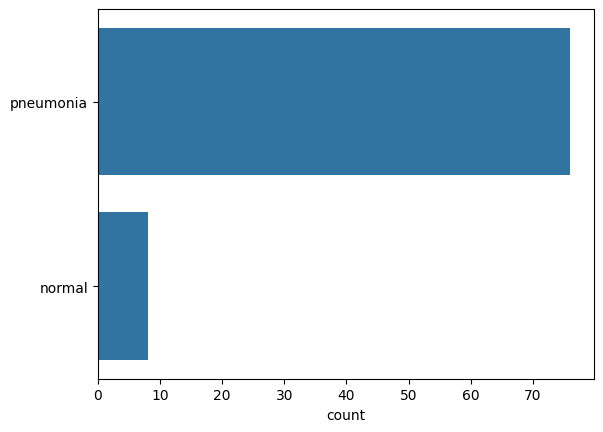

In [51]:
l = []
for i in train:
  if (i[1] == 0):
    l.append('pneumonia')
  else:
    l.append('normal')

sns.countplot(l)

Text(0.5, 1.0, 'Pneumonia')

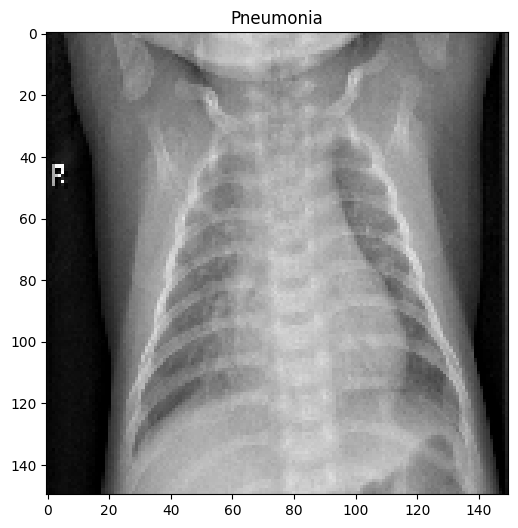

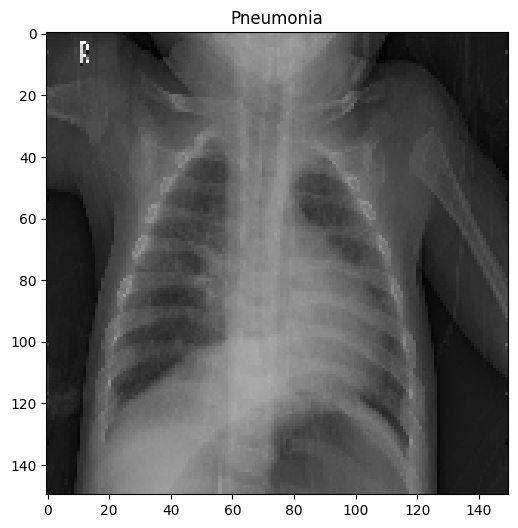

In [52]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])

In [54]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat,label in val:
  x_val.append(feat)
  y_val.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)

In [55]:
#Normalize the data
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [56]:
x_train

array([[[0.05490196, 0.07058824, 0.09803922, ..., 0.02745098,
         0.12941176, 0.28627451],
        [0.07843137, 0.10588235, 0.09803922, ..., 0.        ,
         0.1254902 , 0.29019608],
        [0.08235294, 0.05882353, 0.10196078, ..., 0.01176471,
         0.1254902 , 0.30196078],
        ...,
        [0.04705882, 0.03137255, 0.04705882, ..., 0.00784314,
         0.        , 0.07058824],
        [0.03529412, 0.01568627, 0.02745098, ..., 0.03529412,
         0.        , 0.05882353],
        [0.03137255, 0.01568627, 0.01960784, ..., 0.07843137,
         0.        , 0.05490196]],

       [[0.03921569, 0.0627451 , 0.07058824, ..., 0.05882353,
         0.04313725, 0.02352941],
        [0.03921569, 0.06666667, 0.08235294, ..., 0.05098039,
         0.04705882, 0.02745098],
        [0.03529412, 0.08235294, 0.09019608, ..., 0.07058824,
         0.05098039, 0.03529412],
        ...,
        [0.04705882, 0.04705882, 0.04313725, ..., 0.02745098,
         0.        , 0.        ],
        [0.0

In [57]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

In [58]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

In [59]:
model = Sequential()
model.add(Conv2D(32,(3,3), strides =1, padding='same', activation='relu', input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(128,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(256,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy']) #rmsprop
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [60]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',patience=2,verbose=1,factor=0.3,min_lr=0.000001)

In [61]:
history = model.fit(x_train,y_train,batch_size=32,epochs=18,
                    validation_data=datagen.flow(x_val,y_val),
                    callbacks=[learning_rate_reduction])

Epoch 1/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.6548 - loss: 4.6862 - val_accuracy: 0.5294 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 2/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8929 - loss: 0.5746 - val_accuracy: 0.5882 - val_loss: 0.7932 - learning_rate: 0.0010
Epoch 3/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8452 - loss: 0.4079 - val_accuracy: 0.4706 - val_loss: 1.8575 - learning_rate: 0.0010
Epoch 4/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9397 - loss: 0.1182
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9286 - loss: 0.1477 - val_accuracy: 0.4706 - val_loss: 3.5012 - learning_rate: 0.0010
Epoch 5/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9524 - loss: 0.0971 - val_accuracy: 0.4706 - val_loss: 4.7632 - learning_rate: 3.0000e-04
Epoch 6/18
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9712 - loss: 0.0851
Epoch 6: ReduceLROnPl

In [62]:
model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.9167 - loss: 2.6330


[2.6330173015594482, 0.9166666865348816]

In [63]:
print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100} %")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9167 - loss: 2.6330    
Loss of the model is 2.6330173015594482
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9167 - loss: 2.6330    
Accuracy of the model is 91.66666865348816 %


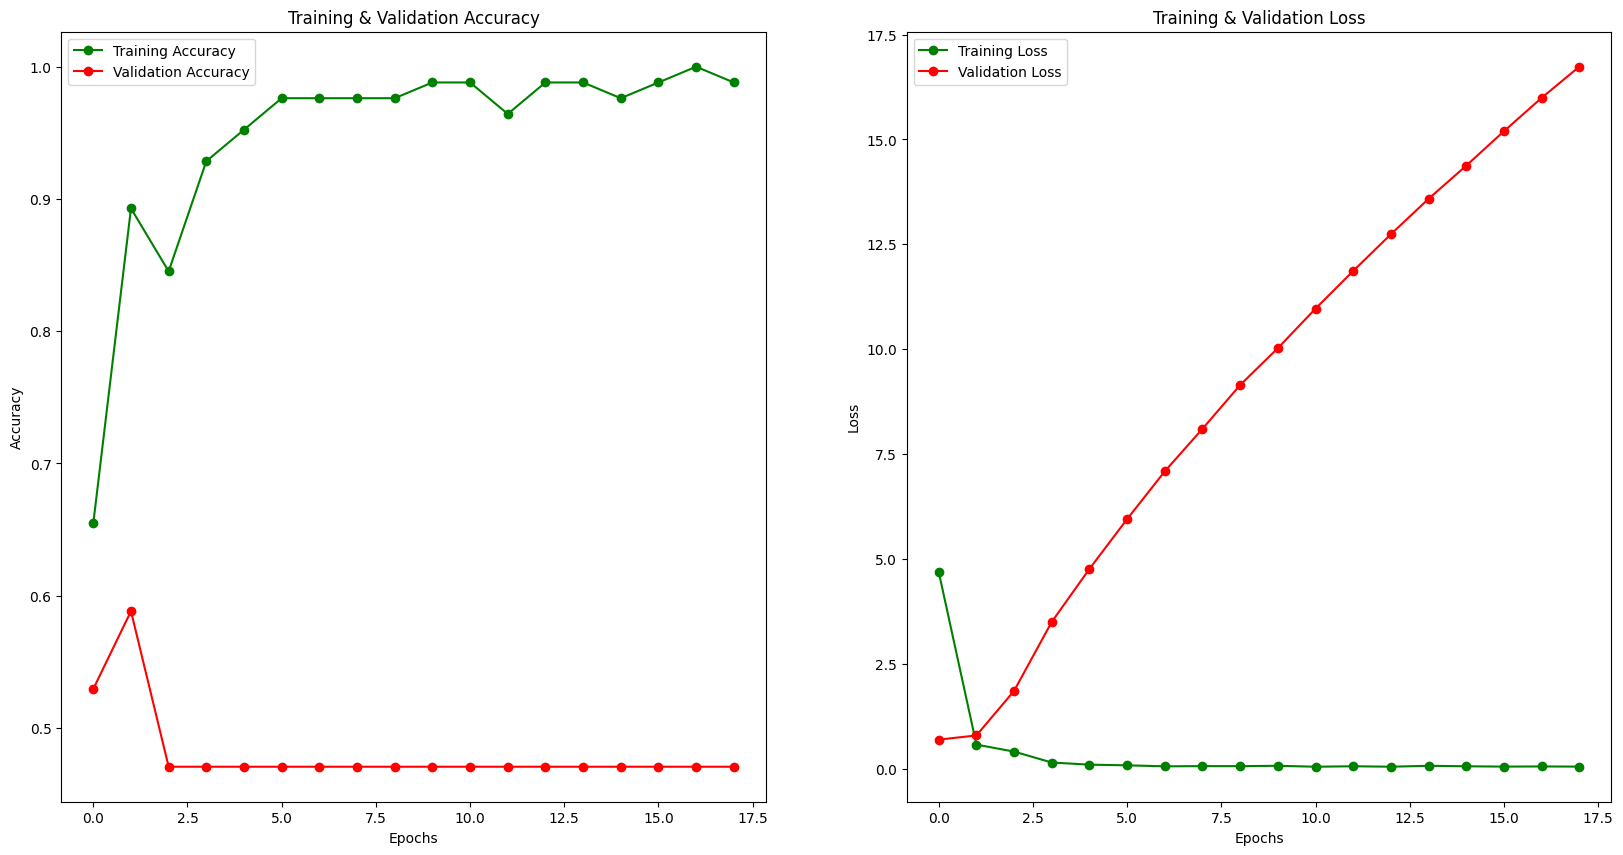

In [64]:
epochs = [i for i in range(18)]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [65]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [66]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.92      1.00      0.96        99
   Normal (Class 1)       0.00      0.00      0.00         9

           accuracy                           0.92       108
          macro avg       0.46      0.50      0.48       108
       weighted avg       0.84      0.92      0.88       108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
cm = confusion_matrix(y_test,predictions)

In [68]:
cm

array([[99,  0],
       [ 9,  0]])

In [70]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

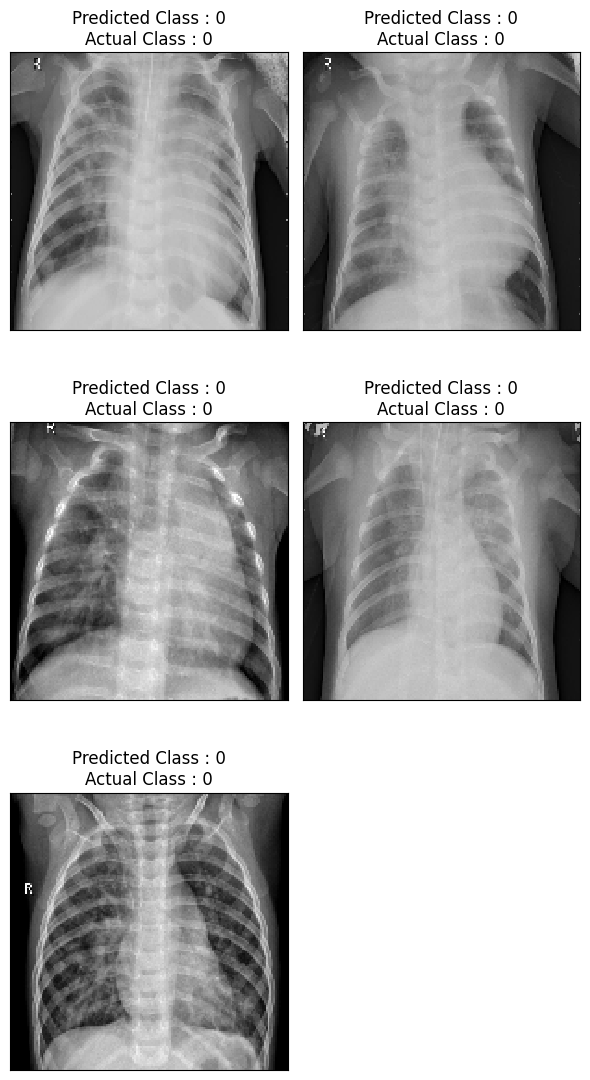

In [71]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[1:6]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

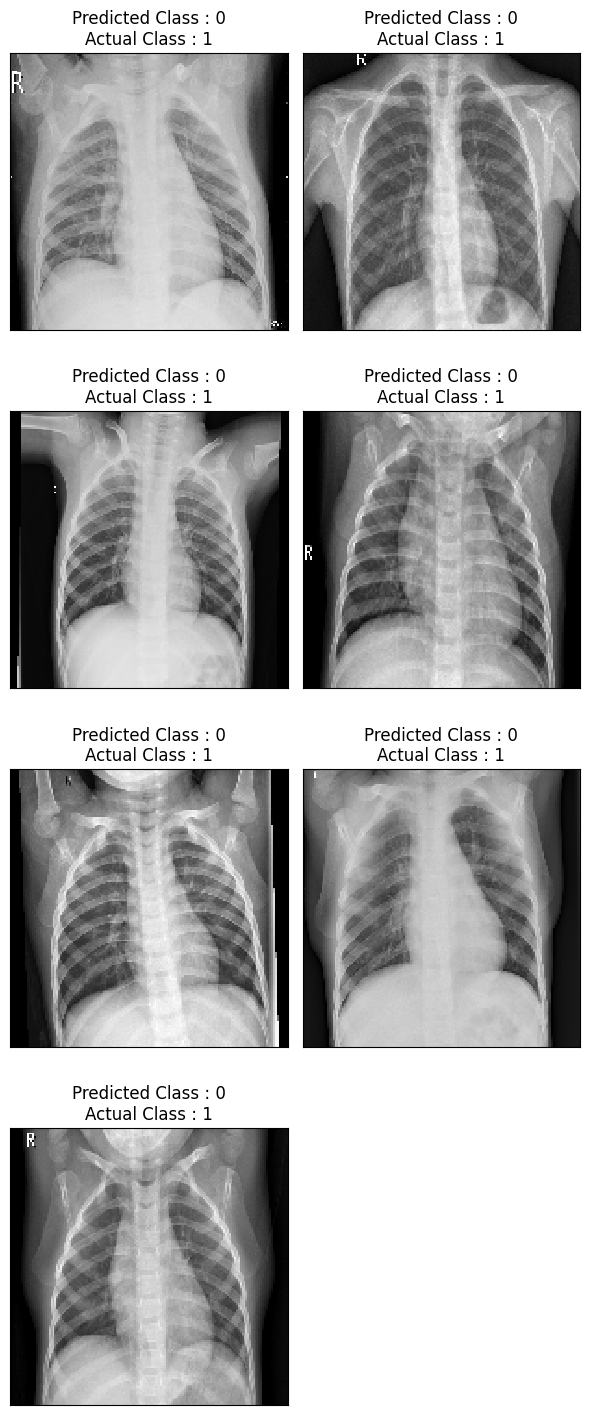

In [72]:
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[1:8]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

In [73]:
# Save the model
model.save('CNN_model.h5')
print ("Model saved successfully!")

Model saved successfully!


In [74]:
import cv2
import numpy as np

img = cv2.imread("/content/sample_data/Train/Pneumonia/person1158_bacteria_3103.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (150,150))

img = img / 255.0

img = np.expand_dims(img, axis=-1)   # (150,150,1)
img = np.expand_dims(img, axis=0)    # (1,150,150,1)

prediction = model.predict(img)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
[[1.6908204e-14]]


In [75]:
if prediction[0][0] > 0.5:
    print("Prediction: NORMAL")
else:
    print("Prediction: PNEUMONIA")

Prediction: PNEUMONIA
